#HoughLines

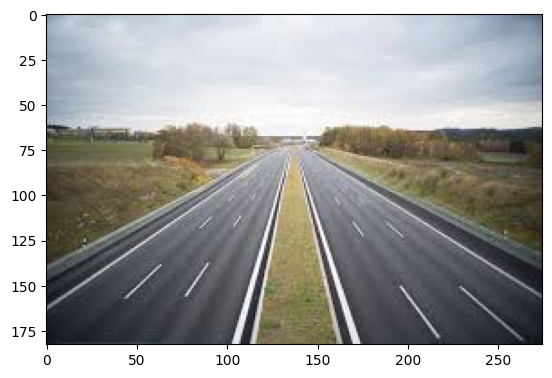

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline
image=cv2.imread('images/lanes1.jpeg')

image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.imshow(image)

(183, 275)


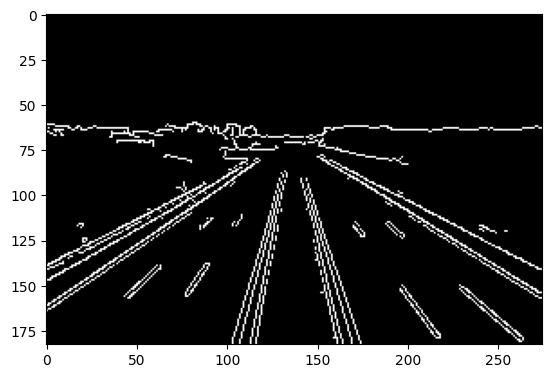

In [ ]:
gray=cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)

low_threshold=150
high_threshold=300
edges=cv2.Canny(gray,low_threshold,high_threshold)

plt.imshow(edges,cmap='gray')

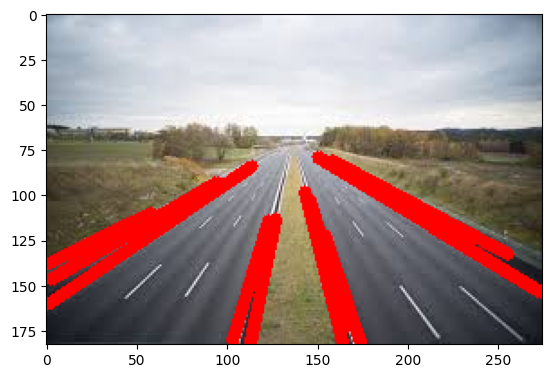

In [10]:
rho=1
theta=np.pi/180
threshold=30
min_line_length=50
max_line_gap=1

line_image=np.copy(image)
lines=cv2.HoughLinesP(edges,rho,theta,threshold,np.array([]),
min_line_length,max_line_gap)

for line in lines:
    for x1,y1,x2,y2 in line:
        cv2.line(line_image,(x1,y1),(x2,y2),(255,0,0),5)

plt.imshow(line_image)

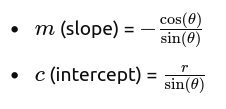

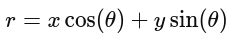

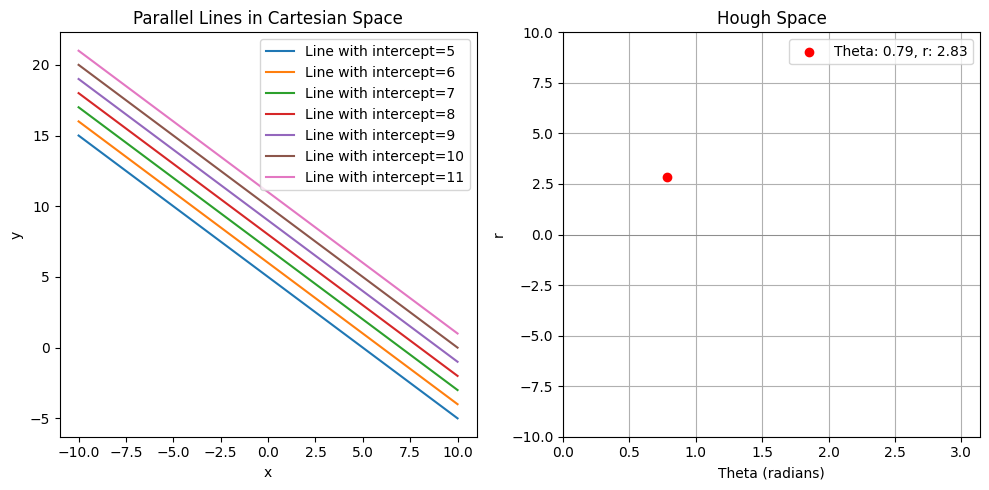

In [4]:
import numpy as np
import matplotlib.pyplot as plt

slope=-1 
intercept=2
theta=np.arctan(-1/slope)
if theta<0:
    theta+=np.pi
    r=intercept/np.sin(theta)

x=np.linspace(-10,10,400)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)

for i in range(3,10):
    y=slope*x+intercept+i 
    plt.plot(x,y,label=f'Linewithintercept={intercept+i}')

plt.title('ParallelLinesinCartesianSpace')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1,2,2)

plt.scatter([theta],[r],color='red',label=f"Theta:{theta:.2f},r:{r:.2f}")
plt.xlabel('Theta(radians)')
plt.ylabel('r')
plt.title('HoughSpace')
plt.xlim(0,np.pi)
plt.ylim(-10,10)
plt.axhline(0,color='gray',lw=0.5)
plt.axvline(0,color='gray',lw=0.5)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


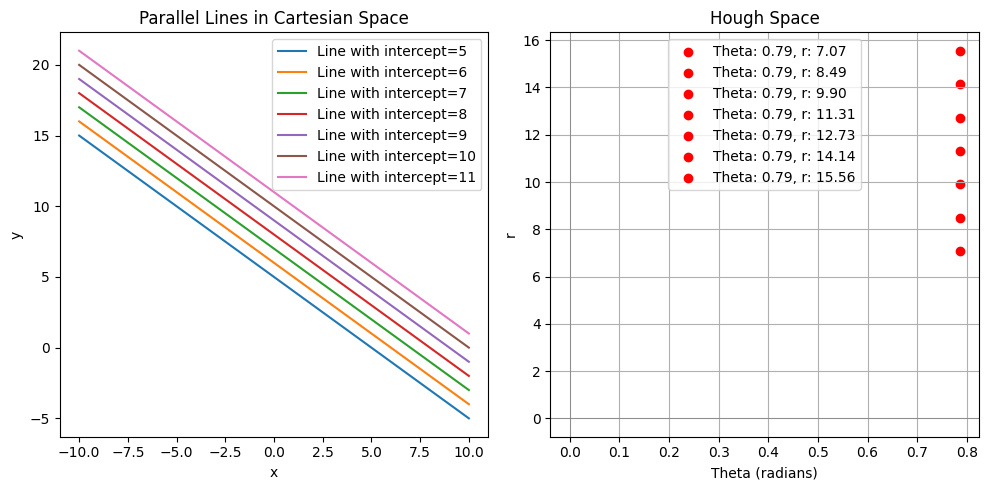

In [7]:
import numpy as np
import matplotlib.pyplot as plt

slope=-1#slopeofthelines
intercept=2#y-interceptofthelines
theta=np.arctan(-1/slope)
if theta<0:
    theta+=np.pi
    r=intercept/np.sin(theta)

x=np.linspace(-10,10,400)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)

for i in range(3,10):
    y=slope*x+intercept+i#Shiftlinesparallel
    plt.plot(x,y,label=f'Linewithintercept={intercept+i}')

plt.title('ParallelLinesinCartesianSpace')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1,2,2)

for i in range(3,10):
    b=intercept+i
    r=b/np.sin(theta)
    plt.scatter([theta],[r],color='red',label=f"Theta:{theta:.2f},r:{r:.2f}")
    plt.xlabel('Theta(radians)')
    plt.ylabel('r')
    plt.title('HoughSpace')
    #plt.xlim(0,np.pi)
    #plt.ylim(-10,10)
    plt.axhline(0,color='gray',lw=0.5)
    plt.axvline(0,color='gray',lw=0.5)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


11


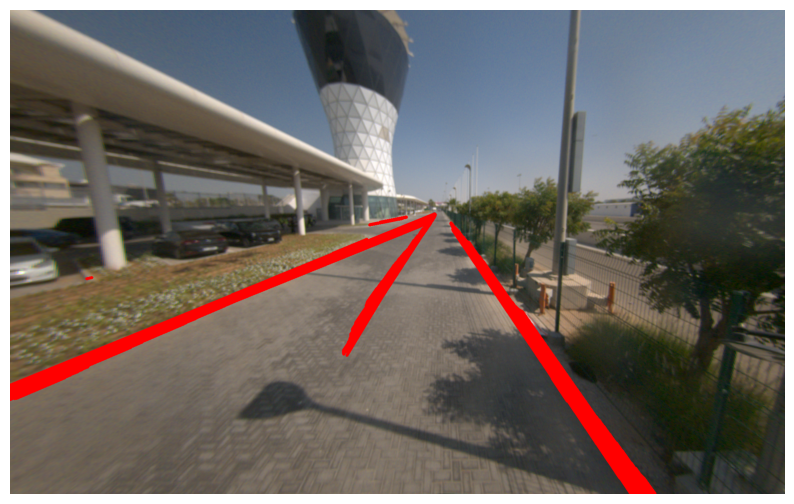

In [83]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/1713937139153798656.png')

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Canny edge detection
edges = cv2.Canny(blur, 150, 300)

# # Masking the region of interest
# height, width = edges.shape
# mask = np.zeros_like(edges)
# polygon = np.array([[
#     (0, height),
#     (width, height),
#     (width, height),
#     (0, height),
# ]], np.int32)
import ast
def read_polygons(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    all_points = []
    for line in lines:
        points = line.strip().split('] [')
        # Clean up the points
        points = [p.replace('[', '').replace(']', '') for p in points]
        # Convert each point to a tuple of floats
        points = [tuple(map(float, point.split())) for point in points]
        all_points.append(points)
    
    return all_points

mask = np.zeros_like(gray)
polygons = read_polygons("images/array.txt")
print(len(polygons))
polygons = [np.array([polygon], dtype=np.int32) for polygon in polygons]
for polygon in polygons:
    cv2.fillPoly(mask, np.array(polygon), 255)

masked_image = cv2.bitwise_and(gray, mask)
# plt.imshow(masked_image)
# masked_edges = cv2.bitwise_or(edges, mask)

# height = edges.shape[0]
# polygons = np.array([
# [(200, height), (1100, height), (550, 250)]
# ])
# mask = np.zeros_like(image)
# cv2.fillPoly(mask, polygons, 255)
# masked_edges = cv2.bitwise_and(edges, mask)

# def region_of_interest(image, polygons):
#     height, width = image.shape
#     polygons = np.array([[
#     (0, height),
#     (width, height),
#     (width, height),
#     (0, height),]], np.int32)
#     mask = np.zeros_like(image)
#     cv2.fillPoly(mask, polygons, 255)
#     masked_image = cv2.bitwise_or(image, mask)
#     return masked_image


# masked_edges = region_of_interest(edges)

# plt.imshow(masked_edges)

# Hough Line Transform
# lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 50, minLineLength=10, maxLineGap=250)
lines = cv2.HoughLinesP(masked_image, 1, np.pi/180, 30, minLineLength=10, maxLineGap=500)
# Draw lines on the image
line_image = np.copy(image)
if lines is not None:
    for line in lines:
        for x1, y1, x2, y2 in line:
            cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 5)

# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(line_image)
plt.axis('off')
plt.show()
